In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import re
import uuid
from scipy import misc
from PIL import Image
import sys
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import time


DATA_DIR = "./FlyingChairs_release/data"
TRAIN_SPLIT = 0.8
BATCH_SIZE = 8

NUM_EPOCHS = 127
LEARNING_RATE = 1e-4

CHECKPOINT_DIR = "./checkpoints"
NUM_CHECKPOINTS_TO_KEEP = 5

START_CHECKPOINT = ""

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_VAL_VIS_SAMPLES = 2

if DEVICE == "cpu":
    print("Running on CPU → using smaller batch size and double precision.")
    BATCH_SIZE = 1
    USE_DOUBLE = True
else:
    print("Running on GPU → using default batch size and float32.")
    USE_DOUBLE = False

Running on GPU → using default batch size and float32.


In [2]:

#IMPORTED FROM THE DATASET PROVIDER

def read(file):
    if file.endswith('.float3'): return readFloat(file)
    elif file.endswith('.flo'): return readFlow(file)
    elif file.endswith('.ppm'): return readImage(file)
    elif file.endswith('.pgm'): return readImage(file)
    elif file.endswith('.png'): return readImage(file)
    elif file.endswith('.jpg'): return readImage(file)
    elif file.endswith('.pfm'): return readPFM(file)[0]
    else: raise Exception('don\'t know how to read %s' % file)

def write(file, data):
    if file.endswith('.float3'): return writeFloat(file, data)
    elif file.endswith('.flo'): return writeFlow(file, data)
    elif file.endswith('.ppm'): return writeImage(file, data)
    elif file.endswith('.pgm'): return writeImage(file, data)
    elif file.endswith('.png'): return writeImage(file, data)
    elif file.endswith('.jpg'): return writeImage(file, data)
    elif file.endswith('.pfm'): return writePFM(file, data)
    else: raise Exception('don\'t know how to write %s' % file)

def readPFM(file):
    file = open(file, 'rb')

    color = None
    width = None
    height = None
    scale = None
    endian = None

    header = file.readline().rstrip()
    if header.decode("ascii") == 'PF':
        color = True
    elif header.decode("ascii") == 'Pf':
        color = False
    else:
        raise Exception('Not a PFM file.')

    dim_match = re.match(r'^(\d+)\s(\d+)\s$', file.readline().decode("ascii"))
    if dim_match:
        width, height = list(map(int, dim_match.groups()))
    else:
        raise Exception('Malformed PFM header.')

    scale = float(file.readline().decode("ascii").rstrip())
    if scale < 0: # little-endian
        endian = '<'
        scale = -scale
    else:
        endian = '>'

    data = np.fromfile(file, endian + 'f')
    shape = (height, width, 3) if color else (height, width)

    data = np.reshape(data, shape)
    data = np.flipud(data)
    return data, scale

def writePFM(file, image, scale=1):
    file = open(file, 'wb')

    color = None

    if image.dtype.name != 'float32':
        raise Exception('Image dtype must be float32.')

    image = np.flipud(image)

    if len(image.shape) == 3 and image.shape[2] == 3:
        color = True
    elif len(image.shape) == 2 or len(image.shape) == 3 and image.shape[2] == 1:
        color = False
    else:
        raise Exception('Image must have H x W x 3, H x W x 1 or H x W dimensions.')

    file.write('PF\n' if color else 'Pf\n'.encode())
    file.write('%d %d\n'.encode() % (image.shape[1], image.shape[0]))

    endian = image.dtype.byteorder

    if endian == '<' or endian == '=' and sys.byteorder == 'little':
        scale = -scale

    file.write('%f\n'.encode() % scale)

    image.tofile(file)

def readFlow(name):
    if name.endswith('.pfm') or name.endswith('.PFM'):
        return readPFM(name)[0][:,:,0:2]

    f = open(name, 'rb')

    header = f.read(4)
    if header.decode("utf-8") != 'PIEH':
        raise Exception('Flow file header does not contain PIEH')

    width = np.fromfile(f, np.int32, 1).squeeze()
    height = np.fromfile(f, np.int32, 1).squeeze()

    flow = np.fromfile(f, np.float32, width * height * 2).reshape((height, width, 2))

    return flow.astype(np.float32)

def readImage(name):
    img = Image.open(name)
    return np.array(img)

def writeImage(name, data):
    if name.endswith('.pfm') or name.endswith('.PFM'):
        return writePFM(name, data, 1)

    return misc.imsave(name, data)

def writeFlow(name, flow):
    f = open(name, 'wb')
    f.write('PIEH'.encode('utf-8'))
    np.array([flow.shape[1], flow.shape[0]], dtype=np.int32).tofile(f)
    flow = flow.astype(np.float32)
    flow.tofile(f)

def readFloat(name):
    f = open(name, 'rb')

    if(f.readline().decode("utf-8"))  != 'float\n':
        raise Exception('float file %s did not contain <float> keyword' % name)

    dim = int(f.readline())

    dims = []
    count = 1
    for i in range(0, dim):
        d = int(f.readline())
        dims.append(d)
        count *= d

    dims = list(reversed(dims))

    data = np.fromfile(f, np.float32, count).reshape(dims)
    if dim > 2:
        data = np.transpose(data, (2, 1, 0))
        data = np.transpose(data, (1, 0, 2))

    return data

def writeFloat(name, data):
    f = open(name, 'wb')

    dim=len(data.shape)
    if dim>3:
        raise Exception('bad float file dimension: %d' % dim)

    f.write(('float\n').encode('ascii'))
    f.write(('%d\n' % dim).encode('ascii'))

    if dim == 1:
        f.write(('%d\n' % data.shape[0]).encode('ascii'))
    else:
        f.write(('%d\n' % data.shape[1]).encode('ascii'))
        f.write(('%d\n' % data.shape[0]).encode('ascii'))
        for i in range(2, dim):
            f.write(('%d\n' % data.shape[i]).encode('ascii'))

    data = data.astype(np.float32)
    if dim==2:
        data.tofile(f)

    else:
        np.transpose(data, (2, 0, 1)).tofile(f)

In [3]:
def read_flow(path):
    with open(path, 'rb') as f:
        _ = np.fromfile(f, np.float32, count=1)
        w = np.fromfile(f, np.int32, count=1)[0]
        h = np.fromfile(f, np.int32, count=1)[0]
        data = np.fromfile(f, np.float32, count=2*w*h)
    return data.reshape(h, w, 2)


def flow_to_rgb(flow):
    fx = flow[..., 0]
    fy = flow[..., 1]

    mag, ang = cv2.cartToPolar(fx, fy)

    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 1] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    hsv[..., 2] = 255

    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def load_sample(idx):
    img1_path = os.path.join(DATA_DIR, f"{idx}_img1.ppm")
    img2_path = os.path.join(DATA_DIR, f"{idx}_img2.ppm")
    flow_path = os.path.join(DATA_DIR, f"{idx}_flow.flo")

    img1 = readImage(img1_path)
    img2 = readImage(img2_path)
    flow = readFlow(flow_path)

    return img1, img2, flow

def visualize_sample(idx):
    img1, img2, flow = load_sample(idx)

    flow_bgr = flow_to_rgb(flow)
    flow_rgb = cv2.cvtColor(flow_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Image 1")
    plt.imshow(img1)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Image 2")
    plt.imshow(img2)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Optical flow (HSV)")
    plt.imshow(flow_rgb)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def plot_batch_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(train_batch_losses, alpha=0.8)
    plt.xlabel("Batch iteration")
    plt.ylabel("EPE Loss")
    plt.title("Training Loss per Batch")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(val_batch_losses, alpha=0.8)
    plt.xlabel("Validation batch iteration")
    plt.ylabel("EPE Loss")
    plt.title("Validation Loss per Batch")
    plt.grid()
    plt.show()

def test_model(model):
    model = model.to(device)

    if TEST_CHECKPOINT:
        if os.path.isfile(TEST_CHECKPOINT):
            ckpt = torch.load(TEST_CHECKPOINT, map_location=device)
            model.load_state_dict(ckpt["model_state"])
            print(f"Loaded checkpoint for testing: {TEST_CHECKPOINT}")
        else:
            print(f"TEST_CHECKPOINT '{TEST_CHECKPOINT}' not found, using current model weights.")
    else:
        print("No TEST_CHECKPOINT set, using current model weights.")

    model.eval()
    total_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for img1, img2, flow_gt in val_loader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            flow_gt = flow_gt.to(device)

            x = torch.cat([img1, img2], dim=1)
            pred_flow = model(x)

            loss = epe_loss(pred_flow, flow_gt)
            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / max(1, num_batches)
    print(f"\nValidation EPE (avg over {num_batches} batches): {avg_loss:.4f}")
    return avg_loss

def visualize_val_samples(model):
    model = model.to(device)
    model.eval()

    img1, img2, flow_gt = next(iter(
        DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
    ))

    img1 = img1.to(device)
    img2 = img2.to(device)
    flow_gt = flow_gt.to(device)

    with torch.no_grad():
        x = torch.cat([img1, img2], dim=1)
        pred_flow = model(x)

    img1 = img1.cpu().numpy()
    img2 = img2.cpu().numpy()
    flow_gt = flow_gt.cpu().numpy()
    pred_flow = pred_flow.cpu().numpy()

    n = min(NUM_VAL_VIS_SAMPLES, img1.shape[0])

    for i in range(n):
        im1 = np.transpose(img1[i], (1, 2, 0))
        im2 = np.transpose(img2[i], (1, 2, 0))
        gt_flow_vis = flow_to_rgb(flow_gt[i].transpose(1, 2, 0))
        pred_flow_vis = flow_to_rgb(pred_flow[i].transpose(1, 2, 0))

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 4, 1)
        plt.title("Val Image 1")
        plt.imshow(im1)
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.title("Val Image 2")
        plt.imshow(im2)
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.title("GT Flow")
        plt.imshow(gt_flow_vis)
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.title("Pred Flow")
        plt.imshow(pred_flow_vis)
        plt.axis("off")

        plt.tight_layout()
        plt.show()


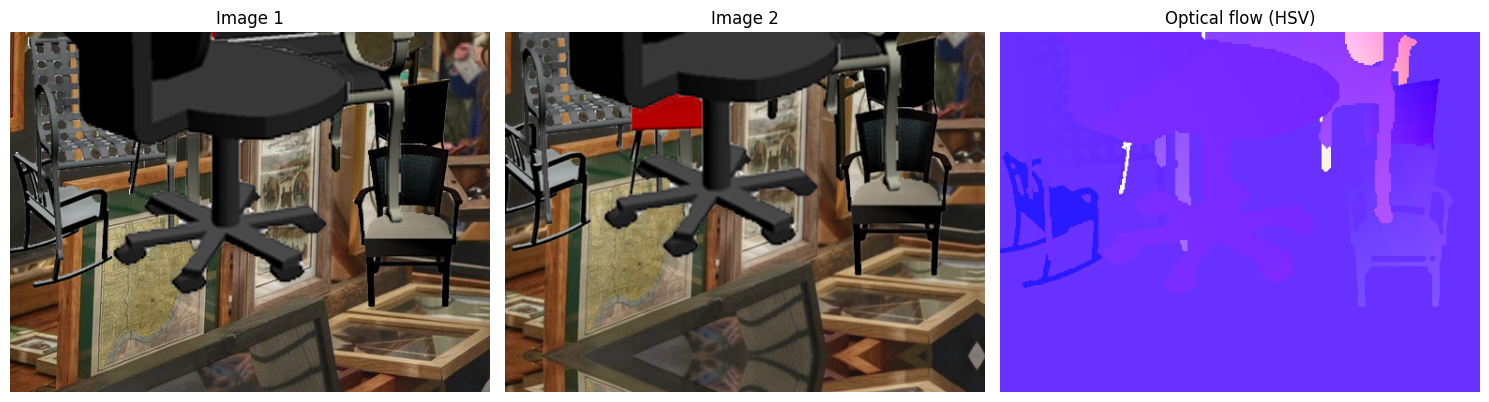

In [4]:
visualize_sample("01016")

In [7]:
class FlyingChairsDataset(Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        img1_path = os.path.join(DATA_DIR, f"{idx}_img1.ppm")
        img2_path = os.path.join(DATA_DIR, f"{idx}_img2.ppm")
        flow_path = os.path.join(DATA_DIR, f"{idx}_flow.flo")

        img1 = readImage(img1_path).astype(np.float32) / 255.0
        img2 = readImage(img2_path).astype(np.float32) / 255.0
        flow = readFlow(flow_path).astype(np.float32)  # H x W x 2

        img1 = torch.from_numpy(img1).permute(2, 0, 1)  # C x H x W
        img2 = torch.from_numpy(img2).permute(2, 0, 1)
        flow = torch.from_numpy(flow).permute(2, 0, 1)  # 2 x H x W

        if USE_DOUBLE:
            img1 = img1.double()
            img2 = img2.double()
            flow = flow.double()

        return img1, img2, flow



def get_indices():
    files = os.listdir(DATA_DIR)
    indices = sorted(set(f.split('_')[0] for f in files if f.endswith("_img1.ppm")))
    return indices


all_indices = get_indices()
num_train = int(len(all_indices) * TRAIN_SPLIT)

train_indices = all_indices[:num_train]
val_indices = all_indices[num_train:]

train_dataset = FlyingChairsDataset(train_indices)
val_dataset = FlyingChairsDataset(val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
INPUT_CHANNELS = 6
DOWN_CH1 = 16
DOWN_CH2 = 32
DOWN_CH3 = 64
BOTTLENECK_CH = 128
FLOW_CHANNELS = 2

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        skip = x
        x = self.pool(x)
        return x, skip


class FlowNetSimple(nn.Module):
    def __init__(self):
        super().__init__()

        in_ch = INPUT_CHANNELS if 'INPUT_CHANNELS' in globals() else 6
        ch1 = DOWN_CH1 if 'DOWN_CH1' in globals() else 16
        ch2 = DOWN_CH2 if 'DOWN_CH2' in globals() else 32
        ch3 = DOWN_CH3 if 'DOWN_CH3' in globals() else 64
        bottleneck_ch = BOTTLENECK_CH if 'BOTTLENECK_CH' in globals() else 128
        flow_ch = FLOW_CHANNELS if 'FLOW_CHANNELS' in globals() else 2

        self.down1 = DownBlock(in_ch, ch1, kernel_size=7)
        self.down2 = DownBlock(ch1, ch2, kernel_size=5)
        self.down3 = DownBlock(ch2, ch3, kernel_size=3)

        self.conv4_1 = nn.Conv2d(ch3, bottleneck_ch, kernel_size=3, padding=1)
        self.bn4_1 = nn.BatchNorm2d(bottleneck_ch)
        self.conv4_2 = nn.Conv2d(bottleneck_ch, bottleneck_ch, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm2d(bottleneck_ch)

        self.up3 = nn.ConvTranspose2d(bottleneck_ch, ch3, kernel_size=2, stride=2)
        self.dec3 = nn.Conv2d(ch3 + ch3, ch3, kernel_size=3, padding=1)

        self.up2 = nn.ConvTranspose2d(ch3, ch2, kernel_size=2, stride=2)
        self.dec2 = nn.Conv2d(ch2 + ch2, ch2, kernel_size=3, padding=1)

        self.up1 = nn.ConvTranspose2d(ch2, ch1, kernel_size=2, stride=2)
        self.dec1 = nn.Conv2d(ch1 + ch1, ch1, kernel_size=3, padding=1)

        self.flow_pred = nn.Conv2d(ch1, flow_ch, kernel_size=1)

    def forward(self, x):
        x1, skip1 = self.down1(x)
        x2, skip2 = self.down2(x1)
        x3, skip3 = self.down3(x2)

        x4 = F.relu(self.bn4_1(self.conv4_1(x3)))
        x4 = F.relu(self.bn4_2(self.conv4_2(x4)))

        u3 = self.up3(x4)
        u3 = torch.cat([u3, skip3], dim=1)
        u3 = F.relu(self.dec3(u3))

        u2 = self.up2(u3)
        u2 = torch.cat([u2, skip2], dim=1)
        u2 = F.relu(self.dec2(u2))

        u1 = self.up1(u2)
        u1 = torch.cat([u1, skip1], dim=1)
        u1 = F.relu(self.dec1(u1))

        flow = self.flow_pred(u1)
        return flow

In [10]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
print('device: ')
print(device)
train_batch_losses = []
val_batch_losses = []  # <--- NEW

model = FlowNetSimple().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

if USE_DOUBLE:
    model = model.double()

def epe_loss(pred, target):
    diff = pred - target
    epe = torch.norm(diff, p=2, dim=1)  # [B, H, W]
    return epe.mean()


def train():
    start_epoch = 0
    global_step = 0
    checkpoint_paths = []

    # Optionally resume from checkpoint
    if START_CHECKPOINT and os.path.isfile(START_CHECKPOINT):
        ckpt = torch.load(START_CHECKPOINT, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt.get("epoch", 0) + 1
        global_step = ckpt.get("global_step", 0)
        checkpoint_paths.append(START_CHECKPOINT)
        print(f"Resumed from {START_CHECKPOINT} at epoch {start_epoch}, step {global_step}")

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        for batch_idx, (img1, img2, flow_gt) in enumerate(train_loader):
            batch_start = time.time()

            img1 = img1.to(device)
            img2 = img2.to(device)
            flow_gt = flow_gt.to(device)
            x = torch.cat([img1, img2], dim=1)  # [B, 6, H, W]
            optimizer.zero_grad()
            pred_flow = model(x)
            loss = epe_loss(pred_flow, flow_gt)
            loss.backward()
            optimizer.step()

            train_batch_losses.append(loss.item())  # already there

            batch_time = time.time() - batch_start
            running_loss += loss.item()
            global_step += 1

            if (batch_idx % 20 == 0):
                print(
                    f"  [Train] Batch {batch_idx+1}/{len(train_loader)} "
                    f"Step {global_step} "
                    f"Loss {loss.item():.4f} "
                    f"Time {batch_time:.3f}s"
            )

        avg_train_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch+1} average train loss: {avg_train_loss:.4f}")

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for img1, img2, flow_gt in val_loader:
                img1 = img1.to(device)
                img2 = img2.to(device)
                flow_gt = flow_gt.to(device)

                x = torch.cat([img1, img2], dim=1)
                pred_flow = model(x)
                loss = epe_loss(pred_flow, flow_gt)
                val_loss_sum += loss.item()
                val_batch_losses.append(loss.item())

        avg_val_loss = val_loss_sum / max(1, len(val_loader))

        print(f"Epoch {epoch+1} average val loss: {avg_val_loss:.4f}")

        ckpt_path = os.path.join(
            CHECKPOINT_DIR, f"flownet_epoch{epoch+1}_step{global_step}.pt"
        )
        torch.save(
            {
                "epoch": epoch,
                "global_step": global_step,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
            },
            ckpt_path,
        )
        checkpoint_paths.append(ckpt_path)

        # keep only the last NUM_CHECKPOINTS_TO_KEEP checkpoints
        if len(checkpoint_paths) > NUM_CHECKPOINTS_TO_KEEP:
            old = checkpoint_paths.pop(0)
            if os.path.exists(old):
                os.remove(old)
                print(f"Removed old checkpoint: {old}")

        print(f"Saved checkpoint: {ckpt_path}")

train()


device: 
cuda

Epoch 1/127
  [Train] Batch 1/2288 Step 1 Loss 11.6342 Time 0.337s
  [Train] Batch 21/2288 Step 21 Loss 6.2399 Time 0.296s
  [Train] Batch 41/2288 Step 41 Loss 14.1660 Time 0.296s
  [Train] Batch 61/2288 Step 61 Loss 14.8464 Time 0.295s
  [Train] Batch 81/2288 Step 81 Loss 13.2549 Time 0.295s
  [Train] Batch 101/2288 Step 101 Loss 12.5559 Time 0.296s
  [Train] Batch 121/2288 Step 121 Loss 11.4509 Time 0.296s
  [Train] Batch 141/2288 Step 141 Loss 6.5393 Time 0.296s
  [Train] Batch 161/2288 Step 161 Loss 9.2407 Time 0.298s
  [Train] Batch 181/2288 Step 181 Loss 15.8188 Time 0.295s
  [Train] Batch 201/2288 Step 201 Loss 16.8812 Time 0.297s
  [Train] Batch 221/2288 Step 221 Loss 15.7043 Time 0.299s
  [Train] Batch 241/2288 Step 241 Loss 8.5661 Time 0.299s
  [Train] Batch 261/2288 Step 261 Loss 15.2420 Time 0.295s
  [Train] Batch 281/2288 Step 281 Loss 15.4785 Time 0.299s
  [Train] Batch 301/2288 Step 301 Loss 11.7265 Time 0.297s
  [Train] Batch 321/2288 Step 321 Loss 14.869

KeyboardInterrupt: 

In [11]:
# Hardcoded file names
TRAIN_FILE = "train_losses.txt"
VAL_FILE = "val_losses.txt"

train_batch_losses = []
val_batch_losses = []
# Append training losses
with open(TRAIN_FILE, "a") as f:
    for loss in train_batch_losses:
        f.write(str(loss) + "\n")

# Append validation losses
with open(VAL_FILE, "a") as f:
    for loss in val_batch_losses:
        f.write(str(loss) + "\n")

print("Losses appended to files:")
print(TRAIN_FILE, "and", VAL_FILE)


Losses appended to files:
train_losses.txt and val_losses.txt


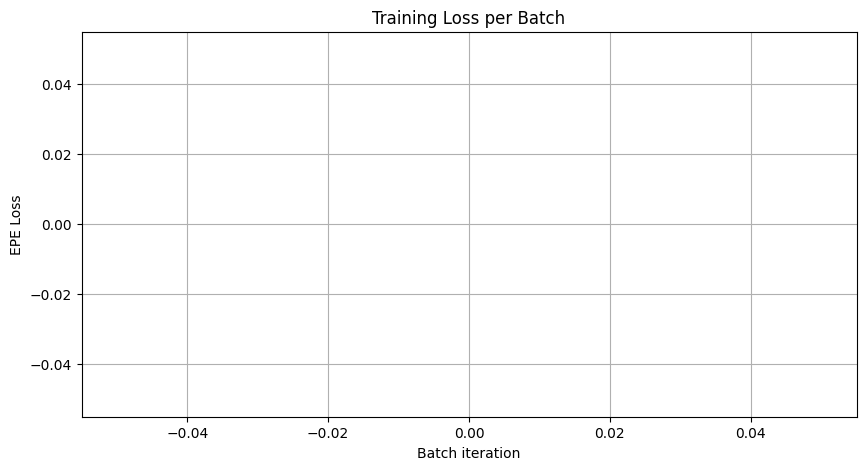

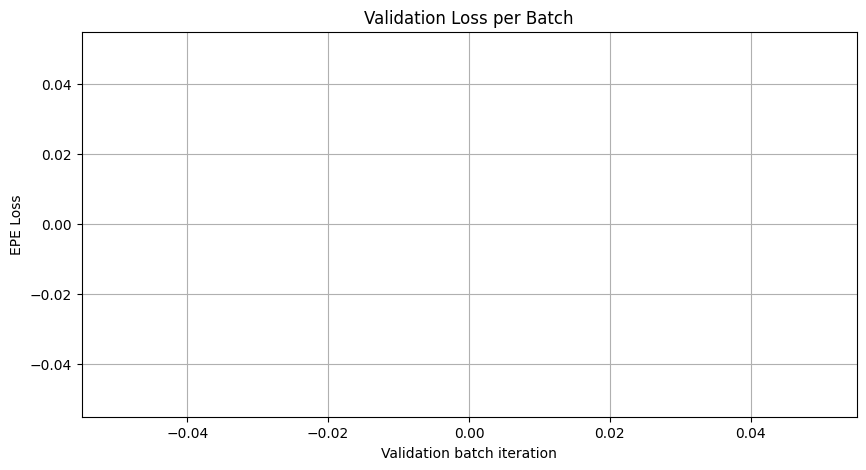

In [10]:
plot_batch_losses()

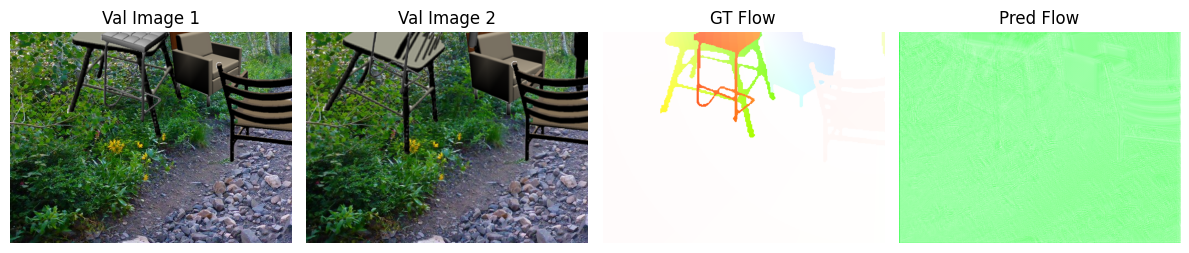

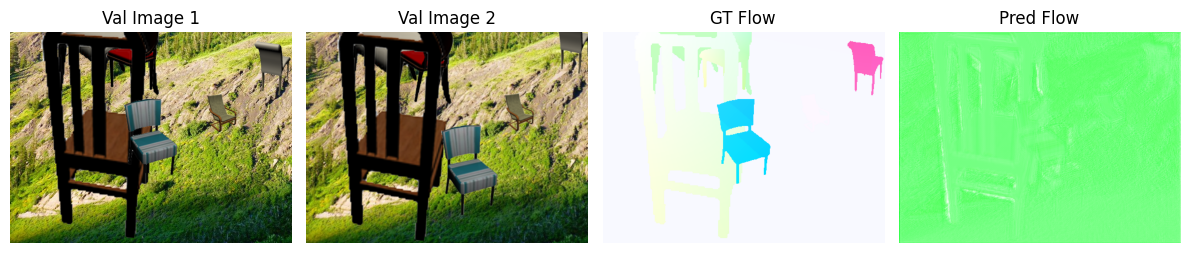

In [14]:
TEST_CHECKPOINT = ""

#model_test = FlowNetSimple().to(device)
visualize_val_samples(model)

